<a href="https://colab.research.google.com/github/TenofJiwon/DerivativeSecurities/blob/main/20260907_Notebook_T1_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nvda = pd.read_excel("/content/Price History_20260906_NVDA.xlsx")
googl = pd.read_excel("/content/Price History_20260906_GOOGL.xlsx")

In [5]:
nvda["Exchange Date"] = pd.to_datetime(nvda["Exchange Date"])
nvda = nvda.sort_values(by='Exchange Date', ascending=True)

googl["Exchange Date"] = pd.to_datetime(googl["Exchange Date"])
googl = googl.sort_values(by='Exchange Date', ascending=True)

In [6]:
combined = googl.merge(nvda,on="Exchange Date", how="left")
combined

,Exchange Date,Close_x,Close_y
0,2004-08-19,2.510808,0.097167
1,2004-08-20,2.710377,0.102917
2,2004-08-23,2.737653,0.105167
3,2004-08-24,2.624293,0.101250
4,2004-08-25,2.652571,0.105583
...,...,...,...
5534,2026-08-19,344.720000,217.560000
5535,2026-08-20,340.670000,216.850000
5536,2026-08-21,344.820000,214.720000
5537,2026-08-24,348.060000,208.480000


In [7]:
combined = combined.rename(columns={"Close_x": "close_googl"})
combined = combined.rename(columns={"Close_y": "close_nvda"})
combined

,Exchange Date,close_googl,close_nvda
0,2004-08-19,2.510808,0.097167
1,2004-08-20,2.710377,0.102917
2,2004-08-23,2.737653,0.105167
3,2004-08-24,2.624293,0.101250
4,2004-08-25,2.652571,0.105583
...,...,...,...
5534,2026-08-19,344.720000,217.560000
5535,2026-08-20,340.670000,216.850000
5536,2026-08-21,344.820000,214.720000
5537,2026-08-24,348.060000,208.480000


In [8]:
combined['return_googl'] = combined["close_googl"] / combined["close_googl"].shift(1)-1
combined['return_nvda'] = combined["close_nvda"] / combined["close_nvda"].shift(1)-1
combined['cumreturn_googl'] = (1 + combined['return_googl']).cumprod() - 1
combined['cumreturn_nvda']  = (1 + combined['return_nvda']).cumprod() - 1
combined

,Exchange Date,close_googl,close_nvda,return_googl,return_nvda,cumreturn_googl,cumreturn_nvda
0,2004-08-19,2.510808,0.097167,NaN,NaN,NaN,NaN
1,2004-08-20,2.710377,0.102917,0.079484,0.059176,0.079484,0.059176
2,2004-08-23,2.737653,0.105167,0.010064,0.021862,0.090347,0.082332
3,2004-08-24,2.624293,0.101250,-0.041408,-0.037246,0.045199,0.042020
4,2004-08-25,2.652571,0.105583,0.010775,0.042795,0.056461,0.086614
...,...,...,...,...,...,...,...
5534,2026-08-19,344.720000,217.560000,0.001511,-0.009921,136.294449,2238.031770
5535,2026-08-20,340.670000,216.850000,-0.011749,-0.003263,134.681422,2230.724763
5536,2026-08-21,344.820000,214.720000,0.012182,-0.009822,136.334276,2208.803740
5537,2026-08-24,348.060000,208.480000,0.009396,-0.029061,137.624698,2144.584406


Text(0, 0.5, 'Cumulative-Returns')

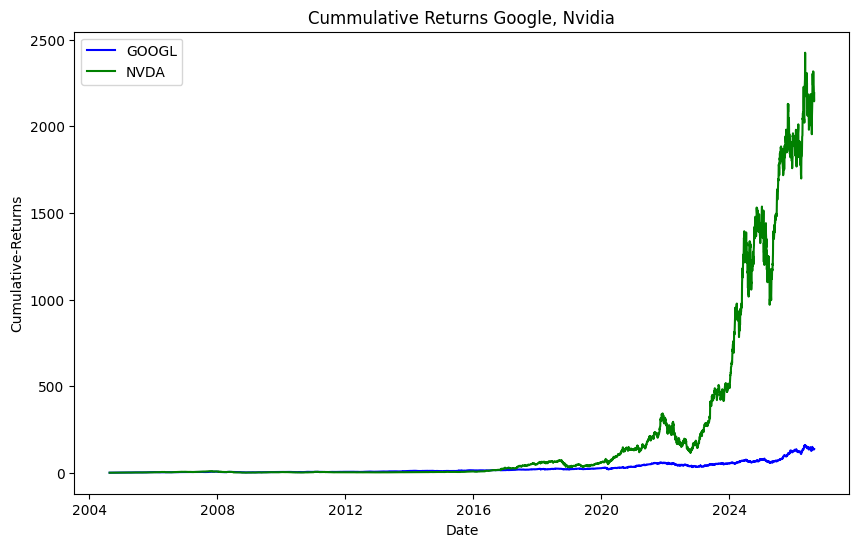

In [17]:
plt.figure(figsize=(10,6))
plt.plot(combined["Exchange Date"], combined["cumreturn_googl"], "blue", label="GOOGL")
plt.plot(combined["Exchange Date"], combined["cumreturn_nvda"], "green", label="NVDA")
plt.title('Cummulative Returns Google, Nvidia')
plt.legend(loc="upper left")
plt.xlabel('Date')
plt.ylabel('Cumulative-Returns')

In [10]:
mean_googl = combined["return_googl"].mean()
mean_nvda = combined["return_nvda"].mean()

var_googl = combined["return_googl"].var()
var_nvda = combined["return_nvda"].var()

std_googl = combined["return_googl"].std()
std_nvda = combined["return_nvda"].std()

In [11]:
print(f"Mean GOOGL: {mean_googl:.4f}")
print(f"Mean NVDA: {mean_nvda:.4f}")
print(f"Variance GOOGL: {var_googl:.4f}")
print(f"Variance NVDA: {var_nvda:.4f}")
print(f"Standard Deviation GOOGL: {std_googl:.4f}")
print(f"Standard Deviation NVDA: {std_nvda:.4f}")

Mean GOOGL: 0.0011
Mean NVDA: 0.0019
Variance GOOGL: 0.0004
Variance NVDA: 0.0009
Standard Deviation GOOGL: 0.0194
Standard Deviation NVDA: 0.0305


In [12]:
mean_googl_ann = mean_googl * 252
mean_nvda_ann = mean_nvda * 252

std_googl_ann = std_googl * np.sqrt(252)
std_nvda_ann = std_nvda * np.sqrt(252)

rf = 0.02

sr_googl = (mean_googl_ann - rf) / std_googl_ann
sr_nvda = (mean_nvda_ann - rf) / std_nvda_ann

In [13]:
print(f"Annual Sharpe Ratio GOOGL: {sr_googl:.4f}")
print(f"Annual Sharpe Ratio NVDA: {sr_nvda:.4f}")

Annual Sharpe Ratio GOOGL: 0.8173
Annual Sharpe Ratio NVDA: 0.9241


In [14]:
cov  = combined['return_googl'].cov(combined['return_nvda'])
corr = combined['return_googl'].corr(combined['return_nvda'])

In [15]:
print(f"Covariance GOOGL & NVDA daily returns: {cov:.4f}")
print(f"Correlation GOOGL & NVDA daily returns: {corr:.4f}")

Covariance GOOGL & NVDA daily returns: 0.0003
Correlation GOOGL & NVDA daily returns: 0.4430


Text(0, 0.5, 'Correlation Coefficient')

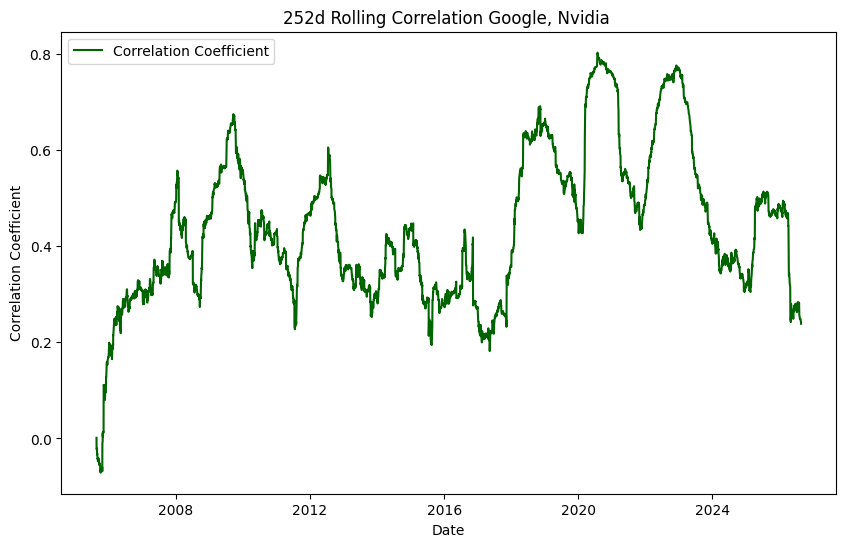

In [16]:
plt.figure(figsize=(10,6))
plt.plot(combined["Exchange Date"], combined['return_googl'].rolling(252).corr(combined['return_nvda']), "darkgreen", label="Correlation Coefficient")
plt.title('252d Rolling Correlation Google, Nvidia ')
plt.legend(loc="upper left")
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient')

